# Import and inputs

In [1]:
# Imports and setup
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

import pandas as pd

repo_root = str(Path("..").resolve())
case_study_root = str(Path(".").resolve())
for path in (repo_root, case_study_root):
    if path not in sys.path:
        sys.path.insert(0, path)

# Notebook-specific imports
from SynFlow.Explorer.sfiller_df import extract_1_slot_col
from SynFlow.SCD import (
    plot_dist_by_period,
    plot_items_dist_contrib_by_period,
    print_dist_contrib_by_period,
    sfillers_dist_contrib_by_period,
)
from SynFlow.SCD.freq import plot_freq_top_union_sfillers_by_period

# Analysis

In [2]:
target_lemma = "viral"
target_pos = "ADJ"  # Use "ALLPOS" to match every POS for target_lemma
period = "1995-2025"
corpus_folder = f"/home/volt/bach/Corpora/deu_news_1995-2025_sentences_parsed"

In [3]:
output_folder = Path(".").resolve()
input_SCD = output_folder / "input" /f"{target_lemma}_{target_pos}_{period}" / "SCD" / "Qual_Insp"
os.makedirs(input_SCD, exist_ok=True)

### Viral

In [19]:
# all_sfillers_df_path = "input/viral_ADJ_1995-2025/SCD/Slot/viral_ADJ_slot_type_df.csv"
all_sfillers_df_path = "input/viral_ADJ_1995-2025/SCD/Slot/viral_ADJ_sfiller_df_token_only_all.csv"
# all_sfillers_df_path = "input/viral_ADJ_1995-2025/SCD/Constr/viral_ADJ_construction_df.csv"
# all_sfillers_df_path = "input/viral_ADJ_1995-2025/SCD/Morph/viral_ADJ_feat_type_df.csv"
# all_sfillers_df_path = "input/viral_ADJ_1995-2025/SCD/Morph/viral_ADJ_feat_df_all.csv"

In [20]:
interest_slot = "pa_amod"
single_slot_df_path = f"{input_SCD}/{target_lemma}_{target_pos}_{interest_slot}.csv"
# Extract the specific slot-filler column
single_slot_df = extract_1_slot_col(all_sfillers_df_path, interest_slot, output_path=single_slot_df_path, explode=False)

In [21]:
# Load dataframe
single_slot_df = pd.read_csv(single_slot_df_path)

# save if needed
single_slot_df.to_csv(single_slot_df_path, index=False)

#### Frequency Changes

In [22]:
# Bar chart (absolute freq)
plot_freq_top_union_sfillers_by_period(single_slot_df_path, 
                              slot_type=interest_slot,
                              top_n=10,
                              normalized=True, # Normalized or Raw count
                              time_col="subfolder",
                              )

#### Distance contribution

In [23]:
sfillers_dist_contrib_results = sfillers_dist_contrib_by_period(single_slot_df, 
                                             slot_col=interest_slot,
                                             min_freq=1, 
                                             period_col="subfolder",
                                             measure="tvd",
                                             weighting=True,
                                             top_n=10,
                                             k=100
                                             )
sfillers_dist_contrib_results
print_dist_contrib_by_period(sfillers_dist_contrib_results)


=== Shift across 1995-2000 vs 2001-2005 ===
TVD: 0.2343
Top shifted items:
  in_('Marketing',): 0.0268
  bo_('Meningitis',): 0.0200
  bo_('Erbsubstanz',): 0.0100
  lo_('Gene',): 0.0096
  lo_('DNA',): 0.0064
  lo_('Genfähren',): 0.0064
  lo_('Infekte',): 0.0064
  lo_('Übeltäter',): 0.0064
  bo_('Eiweiße',): 0.0050
  bo_('Erbguts',): 0.0050

=== Shift across 2001-2005 vs 2006-2010 ===
TVD: 0.2065
Top shifted items:
  de_('Meningitis',): 0.0187
  lo_('Erbsubstanz',): 0.0100
  bo_('Kampagnen',): 0.0093
  bo_('Marketings',): 0.0066
  bo_('Effekte',): 0.0053
  bo_('Verbreitung',): 0.0053
  bo_('Videos',): 0.0053
  lo_('Effekt',): 0.0050
  lo_('Eiweiße',): 0.0050
  lo_('Enzym',): 0.0050

=== Shift across 2006-2010 vs 2011-2015 ===
TVD: 0.7019
Top shifted items:
  de_('Marketing',): 0.0484
  bo_('Hit',): 0.0410
  de_('Kampagnen',): 0.0269
  de_('Marketings',): 0.0208
  de_('Effekte',): 0.0159
  bo_('Infekt',): 0.0149
  bo_('Effekt',): 0.0112
  bo_('Erfolg',): 0.0112
  bo_('Heiratsanträge',): 

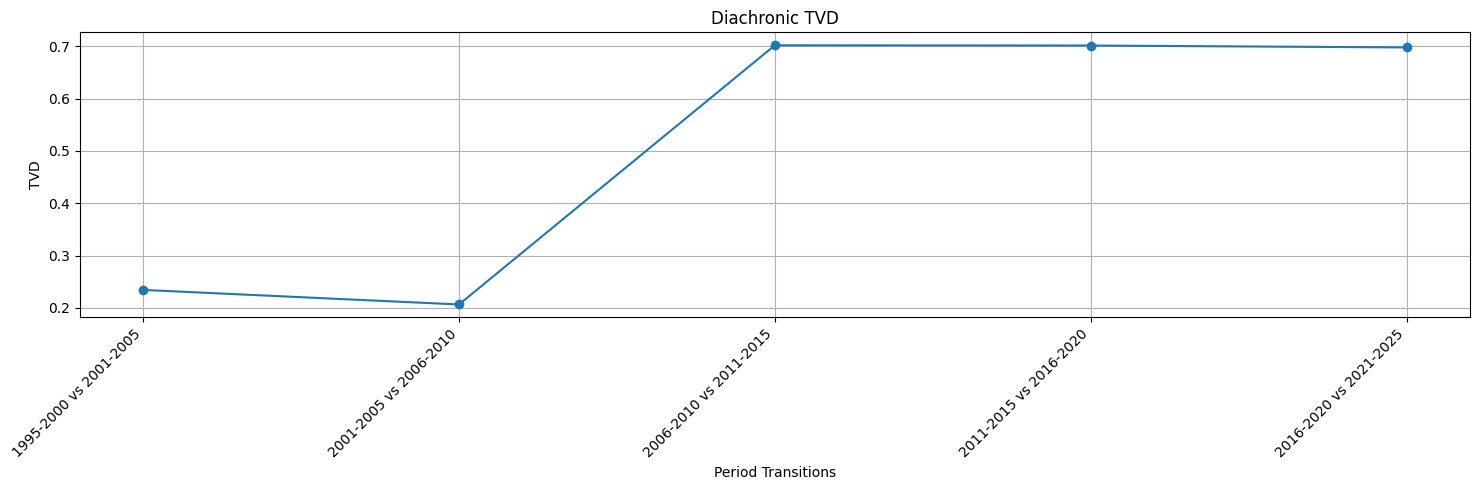

In [24]:
plot_dist_by_period(sfillers_dist_contrib_results)

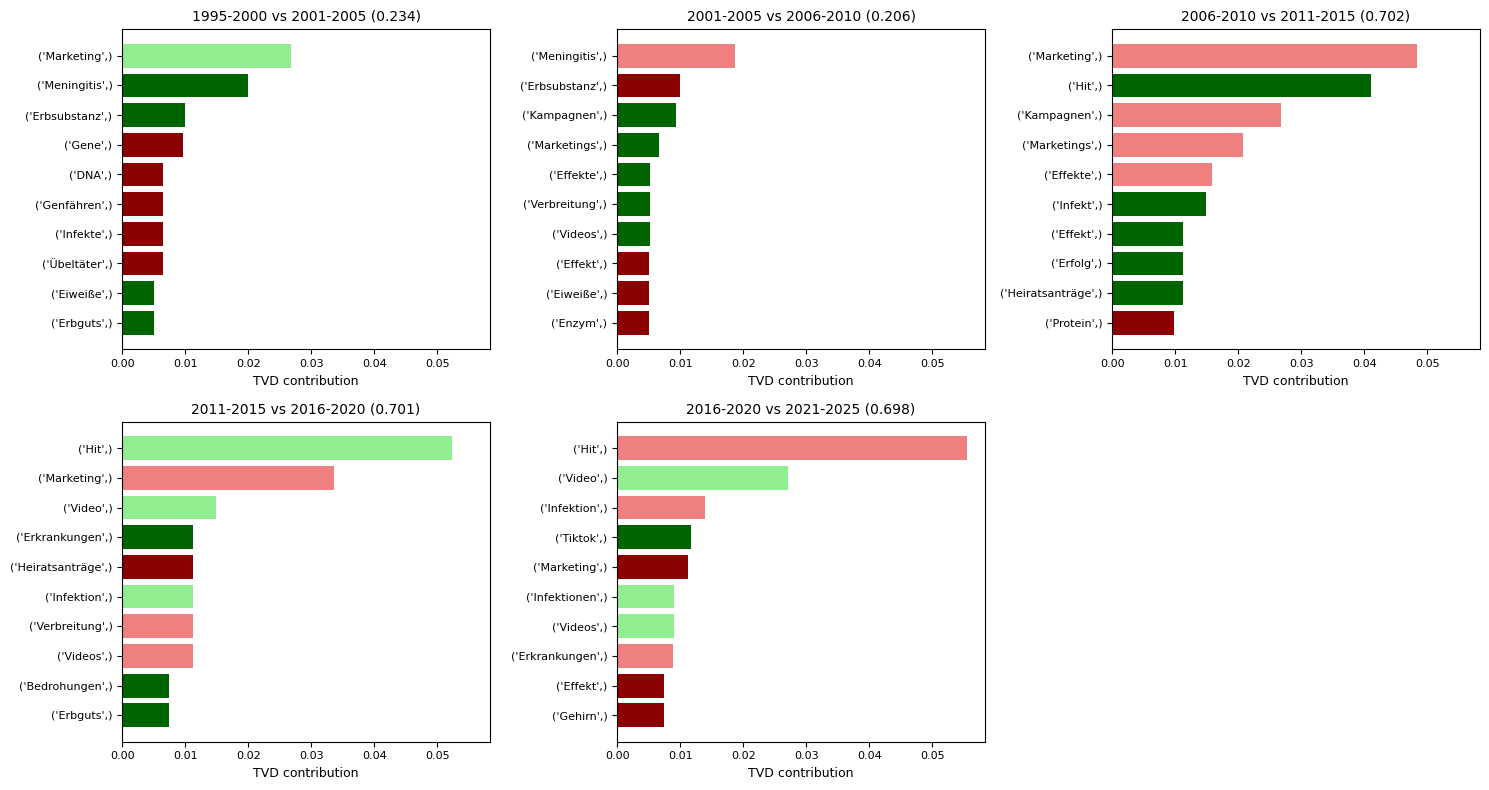

In [25]:
plot_items_dist_contrib_by_period(sfillers_dist_contrib_results, top_n=10, cols=3)